In [1]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [2]:
# Download NVDA historical data and compute daily returns
ticker = yf.Ticker('GOOGL')  # NVIDIA stock ticker
ticker_df = ticker.history(period='max')  # max years of historical data available
ticker_df['Return'] = ticker_df['Close'].pct_change()  # daily return as % change of close price
ticker_df = ticker_df.dropna(how='any')  # drop the first row with NA return
ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]'))  # make index yyyy-mm-dd
ticker_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Return
2004-08-20,2.507057,2.707353,2.494399,2.688241,456686856,0.0,0.0,0.079430
2004-08-23,2.748803,2.816561,2.706609,2.715296,365122512,0.0,0.0,0.010064
2004-08-24,2.760964,2.769900,2.570596,2.602861,304946748,0.0,0.0,-0.041408
2004-08-25,2.605096,2.680548,2.578290,2.630908,183772044,0.0,0.0,0.010775
2004-08-26,2.604847,2.679307,2.597649,2.678314,141897960,0.0,0.0,0.018019
...,...,...,...,...,...,...,...,...
2026-03-19,304.010010,308.059998,302.350006,307.130005,25075800,0.0,0.0,-0.001820
2026-03-20,305.459991,306.000000,298.269989,301.000000,44364100,0.0,0.0,-0.019959
2026-03-23,302.109985,305.980011,300.929993,302.059998,29326900,0.0,0.0,0.003522
2026-03-24,299.200012,299.920013,290.329987,290.440002,36864300,0.0,0.0,-0.038469


In [15]:
# Mean Absolute Deviation around the mean
ticker_mean_mad = (ticker_df['Return'] - ticker_df['Return'].mean()).abs().mean()
ticker_mean_mad

np.float64(0.013115115943468316)

In [16]:
# Median Absolute Deviation (c=1 means no scaling constant)
ticker_median_mad = robust.mad(ticker_df['Return'], c=1)
ticker_median_mad

np.float64(0.009141594799262076)

In [17]:
# Skewness
ticker_skewness = ticker_df['Return'].skew()
ticker_skewness

np.float64(0.6015266137600707)

In [18]:
# Pearson Kurtosis (fisher=False keeps the raw kurtosis; normal distribution = 3)
# The expected output shows ~10.7, which matches Pearson (non-excess) kurtosis
ticker_kurtosis = stats.kurtosis(ticker_df['Return'], fisher=False)
ticker_kurtosis

np.float64(11.827219496542872)

In [19]:
# Standard describe() statistics
ticker_describe = ticker_df['Return'].describe()
ticker_describe

count    5432.000000
mean        0.001061
std         0.019278
min        -0.116341
25%        -0.008044
50%         0.000875
75%         0.010262
max         0.199915
Name: Return, dtype: float64

In [20]:
# Build the additional stats (mean_mad, median_mad, skewness, kurtosis) as a single-column DataFrame
ticker_misc = pd.DataFrame(
    [ticker_mean_mad, ticker_median_mad, ticker_skewness, ticker_kurtosis],
    index=['mean_mad', 'median_mad', 'skewness', 'kurtosis'],
    columns=['Return']
)
ticker_misc

,Return
mean_mad,0.013115
median_mad,0.009142
skewness,0.601527
kurtosis,11.827219


In [21]:
# Combine describe() output with the additional stats into one single-column summary DataFrame
ticker_des_stats = pd.concat([ticker_describe.to_frame(), ticker_misc], axis=0)
ticker_des_stats

,Return
count,5432.000000
mean,0.001061
std,0.019278
min,-0.116341
25%,-0.008044
50%,0.000875
75%,0.010262
max,0.199915
mean_mad,0.013115
median_mad,0.009142


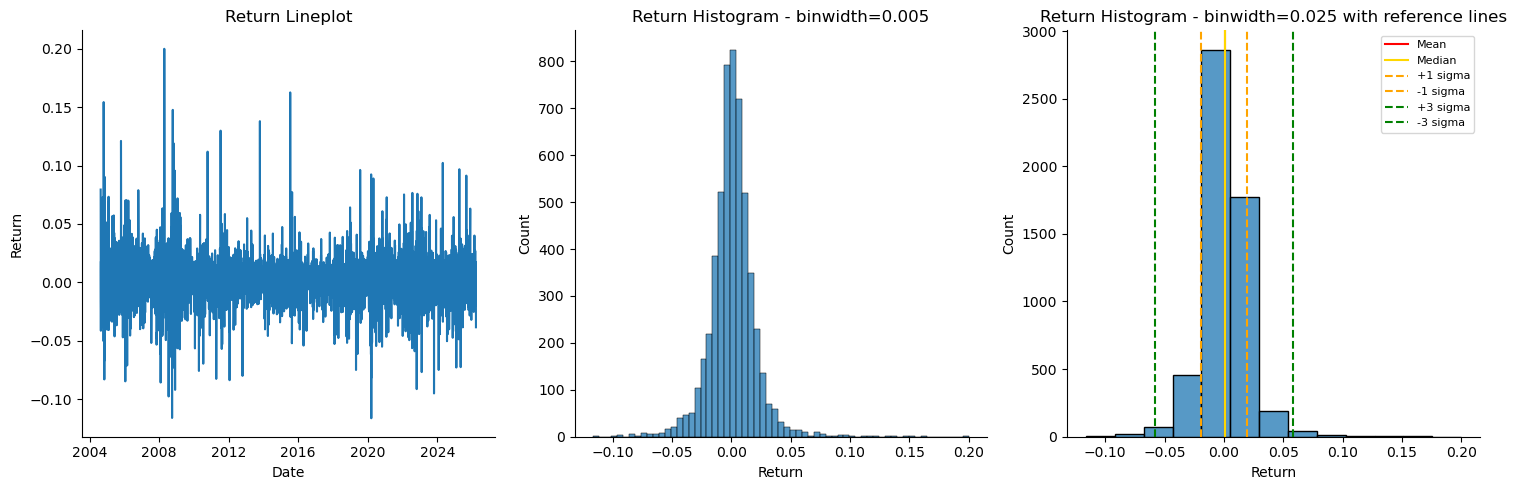

In [22]:
# Generate a 3-subplot figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Line plot of daily returns
ax0 = sns.lineplot(data=ticker_df['Return'], ax=axes[0])
axes[0].set_title("Return Lineplot")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Return")

# Subplot 2: Histogram with binwidth=0.005
ax1 = sns.histplot(data=ticker_df['Return'], binwidth=0.005, ax=axes[1])
axes[1].set_title("Return Histogram - binwidth=0.005")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Count")

# Subplot 3: Histogram with binwidth=0.025 and reference lines
ax2 = sns.histplot(data=ticker_df['Return'], binwidth=0.025, ax=axes[2])  # correct binwidth
axes[2].set_title("Return Histogram - binwidth=0.025 with reference lines")
axes[2].set_xlabel("Return")
axes[2].set_ylabel("Count")

mean_val   = ticker_df['Return'].mean()
median_val = ticker_df['Return'].median()
std_val    = ticker_df['Return'].std()

# Mean (red solid)
axes[2].axvline(mean_val,       color='red',    linestyle='solid',  linewidth=1.5, label='Mean')
# Median (gold solid)
axes[2].axvline(median_val,     color='gold',   linestyle='solid',  linewidth=1.5, label='Median')
# +/- 1 sigma (orange dashed)
axes[2].axvline( std_val,       color='orange', linestyle='dashed', linewidth=1.5, label='+1 sigma')
axes[2].axvline(-std_val,       color='orange', linestyle='dashed', linewidth=1.5, label='-1 sigma')
# +/- 3 sigma (green dashed)
axes[2].axvline( 3 * std_val,   color='green',  linestyle='dashed', linewidth=1.5, label='+3 sigma')
axes[2].axvline(-3 * std_val,   color='green',  linestyle='dashed', linewidth=1.5, label='-3 sigma')

axes[2].legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
ticker_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Return
2004-08-20,2.507057,2.707353,2.494399,2.688241,456686856,0.0,0.0,0.079430
2004-08-23,2.748803,2.816561,2.706609,2.715296,365122512,0.0,0.0,0.010064
2004-08-24,2.760965,2.769900,2.570596,2.602861,304946748,0.0,0.0,-0.041408
2004-08-25,2.605096,2.680548,2.578290,2.630908,183772044,0.0,0.0,0.010775
2004-08-26,2.604847,2.679307,2.597650,2.678314,141897960,0.0,0.0,0.018019
